In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report
from sklearn.metrics.pairwise import cosine_similarity
import json, warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


In [2]:
# Load the cleaned ATS pairs dataset
df = pd.read_csv('cleaned_resumeJD_pairs.csv')
print(f'Loaded: {len(df)} pairs')
print(f'\nLabel distribution:')
print(df['match_label'].value_counts())
print(f'\nScore range: {df["match_score"].min():.2f} – {df["match_score"].max():.2f}')
df.head(3)


Loaded: 266 pairs

Label distribution:
match_label
high      116
medium     87
low        63
Name: count, dtype: int64

Score range: 0.00 – 0.95


,resume_text,job_description,match_score,match_label,match_label_lower,resume_len,jd_len
0,Senior data analyst with 6 years of experience...,Senior Business Intelligence Analyst at enterp...,0.90,high,high,60,30
1,Full stack developer with 5 years of experienc...,Full Stack Engineer at startup. Required skill...,0.92,high,high,55,21
2,Cybersecurity analyst with 5 years of experien...,Cybersecurity Analyst at enterprise firm. Requ...,0.88,high,high,55,23


In [4]:
#Train / Val / Test Split
#Stratify by match_label so each split has balanced high/medium/low

train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['match_label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['match_label']
)

print(f'Train:      {len(train_df)} pairs')
print(f'Validation: {len(val_df)} pairs')
print(f'Test:       {len(test_df)} pairs')
print()

# Verify each split has all 3 labels
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name} label dist: {split["match_label"].value_counts().to_dict()}')


Train:      186 pairs
Validation: 40 pairs
Test:       40 pairs

Train label dist: {'high': 81, 'medium': 61, 'low': 44}
Val label dist: {'high': 17, 'medium': 13, 'low': 10}
Test label dist: {'high': 18, 'medium': 13, 'low': 9}


In [5]:
#Convert to InputExample format — sentence-transformers expects this
#text1 = resume, text2 = job description, label = match_score (float 0-1)

train_examples = [
    InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in train_df.iterrows()
]

val_examples = [
    InputExample(texts=[row['resume_text'], row['job_description']], label=float(row['match_score']))
    for _, row in val_df.iterrows()
]

print(f'Train examples: {len(train_examples)}')
print(f'Val examples:   {len(val_examples)}')
print(f'\nSample InputExample:')
print(f'  text1 (resume): {train_examples[0].texts[0][:80]}...')
print(f'  text2 (JD):     {train_examples[0].texts[1][:80]}...')
print(f'  label:          {train_examples[0].label}')


Train examples: 186
Val examples:   40

Sample InputExample:
  text1 (resume): Event manager with 7 years of experience planning large-scale corporate events a...
  text2 (JD):     Senior DevOps Engineer at a cloud-native company. Required skills: AWS, Kubernet...
  label:          0.06


In [6]:
#Base Model Baseline
print('Loading base BERT model...')
base_model = SentenceTransformer('all-mpnet-base-v2')
print('Loaded.')


Loading base BERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded.


In [7]:
# Evaluate base model on test set BEFORE fine-tuning
# This is our baseline, fine-tuning should beat this
print('Evaluating base model on test set...')

base_preds = []
for _, row in test_df.iterrows():
    emb1 = base_model.encode(row['resume_text'])
    emb2 = base_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]
    base_preds.append(float(sim))

base_mae  = mean_absolute_error(test_df['match_score'], base_preds)
base_rmse = np.sqrt(mean_squared_error(test_df['match_score'], base_preds))

print(f'\nBase Model — Test Set Performance')
print(f'  MAE:  {base_mae:.4f}')
print(f'  RMSE: {base_rmse:.4f}')
print()
print('Goal: fine-tuning should reduce MAE below this number.')

Evaluating base model on test set...

Base Model — Test Set Performance
  MAE:  0.1562
  RMSE: 0.1791

Goal: fine-tuning should reduce MAE below this number.


In [8]:
#Fine-Tune BERT

# Fresh model instance for fine-tuning (don't reuse base_model)
model = SentenceTransformer('all-mpnet-base-v2')

# DataLoader, shuffles training data each epoch
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# CosineSimilarityLoss: trains the model so that
# cosine_similarity(embed(resume), embed(jd)) ≈ match_score
train_loss = losses.CosineSimilarityLoss(model)

# Evaluator runs on val set after each evaluation_steps
evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples, name='ats-val'
)

print('Training setup ready.')
print(f'  Batch size:   16')
print(f'  Train pairs:  {len(train_examples)}')
print(f'  Steps/epoch:  {len(train_dataloader)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training setup ready.
  Batch size:   16
  Train pairs:  186
  Steps/epoch:  12


In [ ]:
# Fine-tune
# epochs=10 is reasonable for 200-250 training pairs
# warmup_steps = 10% of total steps

total_steps   = len(train_dataloader) * 10
warmup_steps  = int(total_steps * 0.1)

print(f'Total steps:  {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'\nStarting fine-tuning...\n')

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=10,
    evaluation_steps=len(train_dataloader),   # evaluate once per epoch
    warmup_steps=warmup_steps,
    output_path='models/finetuned-bert',
    save_best_model=True,
    show_progress_bar=True
)

print('\nFine-tuning complete!')

Total steps:  120
Warmup steps: 12

Starting fine-tuning...



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Ats-val Pearson Cosine,Ats-val Spearman Cosine
12,No log,No log,0.966014,0.832881
24,No log,No log,0.972630,0.861267
36,No log,No log,0.971595,0.863993
48,No log,No log,0.970138,0.849142
60,No log,No log,0.968526,0.847074
72,No log,No log,0.969094,0.844818
84,No log,No log,0.969453,0.844818
96,No log,No log,0.969470,0.838896
108,No log,No log,0.969345,0.840964
120,No log,No log,0.969352,0.840964


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning complete!


In [10]:
#Evaluate Fine-Tuned Model

finetuned_model = SentenceTransformer('models/finetuned-bert')
print('Fine-tuned model loaded.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded.


In [11]:
ft_preds = []
for _, row in test_df.iterrows():
    emb1 = finetuned_model.encode(row['resume_text'])
    emb2 = finetuned_model.encode(row['job_description'])
    sim  = cosine_similarity([emb1], [emb2])[0][0]
    ft_preds.append(float(sim))

ft_mae  = mean_absolute_error(test_df['match_score'], ft_preds)
ft_rmse = np.sqrt(mean_squared_error(test_df['match_score'], ft_preds))

print(f'\nFine-tuned Model — Test Set Performance')
print(f'  MAE:  {ft_mae:.4f}')
print(f'  RMSE: {ft_rmse:.4f}')


Fine-tuned Model — Test Set Performance
  MAE:  0.0468
  RMSE: 0.0665


In [12]:
# Side-by-side comparison
print('=' * 50)
print('MODEL COMPARISON')
print('=' * 50)
print(f'  Base MAE:         {base_mae:.4f}')
print(f'  Fine-tuned MAE:   {ft_mae:.4f}')
print(f'  Improvement:      {(base_mae - ft_mae)/base_mae*100:.1f}%')
print('=' * 50)

MODEL COMPARISON
  Base MAE:         0.1562
  Fine-tuned MAE:   0.0468
  Improvement:      70.0%


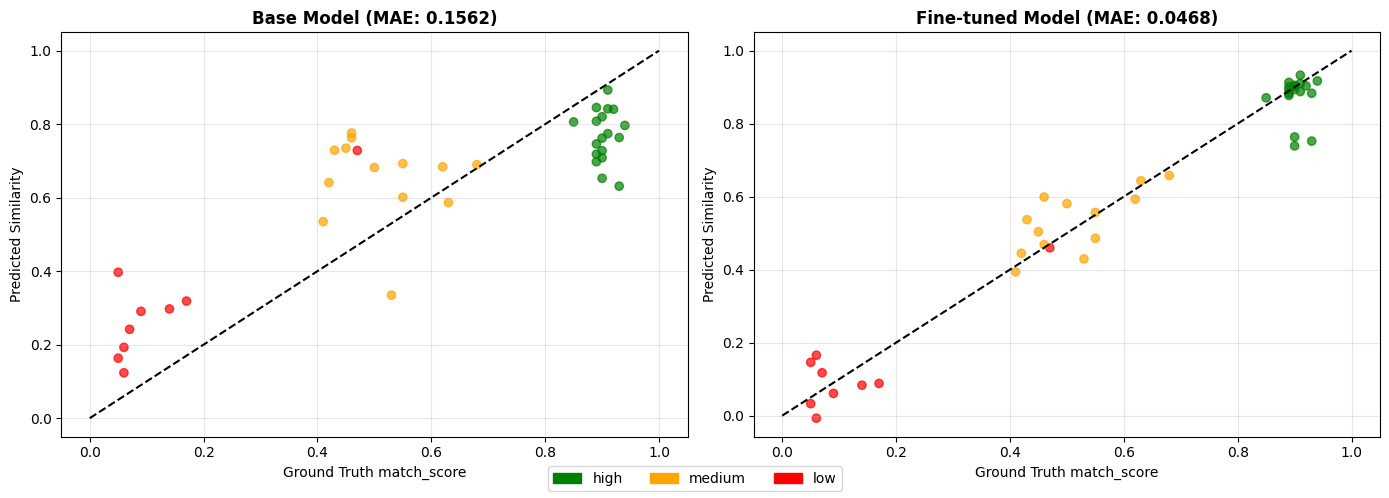

In [13]:
# Scatter plots: base vs fine-tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = test_df['match_label'].map({'low':'red','medium':'orange','high':'green'})

for ax, preds, title, mae in [
    (axes[0], base_preds, 'Base Model', base_mae),
    (axes[1], ft_preds,   'Fine-tuned Model', ft_mae),
]:
    ax.scatter(test_df['match_score'], preds, c=colors, alpha=0.7)
    ax.plot([0,1],[0,1],'k--', label='Perfect')
    ax.set_xlabel('Ground Truth match_score')
    ax.set_ylabel('Predicted Similarity')
    ax.set_title(f'{title} (MAE: {mae:.4f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color='green', label='high'),
    Patch(color='orange', label='medium'),
    Patch(color='red', label='low'),
], loc='lower center', ncol=3)
plt.tight_layout()
plt.show()

In [14]:
metadata = {
    'base_model':       'all-mpnet-base-v2',
    'dataset':          'merged_dataset_clean.csv',
    'total_pairs':      len(df),
    'train_pairs':      len(train_df),
    'val_pairs':        len(val_df),
    'test_pairs':       len(test_df),
    'epochs':           10,
    'batch_size':       16,
    'base_mae':         round(float(base_mae), 4),
    'finetuned_mae':    round(float(ft_mae), 4),
    'improvement_pct':  round((base_mae - ft_mae) / base_mae * 100, 2),
}

with open('models/finetuned-bert/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: models/finetuned-bert/')
print(json.dumps(metadata, indent=2))

Saved: models/finetuned-bert/
{
  "base_model": "all-mpnet-base-v2",
  "dataset": "merged_dataset_clean.csv",
  "total_pairs": 266,
  "train_pairs": 186,
  "val_pairs": 40,
  "test_pairs": 40,
  "epochs": 10,
  "batch_size": 16,
  "base_mae": 0.1562,
  "finetuned_mae": 0.0468,
  "improvement_pct": 70.01
}


In [ ]:
#Production Pipeline Test

def score_resume_against_jd(resume_text, jd_text, model):
 
    emb_resume = model.encode(resume_text, convert_to_numpy=True)
    emb_jd     = model.encode(jd_text,     convert_to_numpy=True)
    score      = cosine_similarity([emb_resume], [emb_jd])[0][0]
    return float(score)


# Test with realistic cases
test_cases = [
    {
        'label':  'HIGH match expected',
        'resume': 'Senior Python developer with 6 years experience. Built REST APIs using FastAPI and Django. Proficient in PostgreSQL, Docker, and AWS deployment.',
        'jd':     'We need a Python backend engineer with FastAPI or Django experience. Must know SQL databases and cloud deployment.',
    },
    {
        'label':  'MEDIUM match expected',
        'resume': 'Frontend developer with 3 years React and TypeScript experience. Some Node.js and Express for small APIs.',
        'jd':     'Full stack engineer needed. React frontend required, strong Python backend preferred. 4+ years experience.',
    },
    {
        'label':  'LOW match expected',
        'resume': 'Executive Chef with 12 years experience in fine dining. Expert in French cuisine, menu planning, and kitchen management.',
        'jd':     'Data Scientist with Python, machine learning, and SQL experience required.',
    },
]

print('Production Pipeline Test')
print('=' * 60)
for case in test_cases:
    score = score_resume_against_jd(case['resume'], case['jd'], finetuned_model)
    label = 'HIGH' if score > 0.70 else 'MEDIUM' if score > 0.45 else 'LOW'
    print(f"\n{case['label']}")
    print(f"  Predicted score: {score:.4f}  →  {label}")


Production Pipeline Test

HIGH match expected
  Predicted score: 0.7925  →  HIGH

MEDIUM match expected
  Predicted score: 0.6910  →  MEDIUM

LOW match expected
  Predicted score: 0.0359  →  LOW
